In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (14, 8), 'font.size': 12,
    'axes.titlesize': 16, 'axes.labelsize': 13,
    'font.family': ['Hiragino Sans', 'sans-serif'],
})

# Load data
with open('../dj_sets.json') as f:
    raw_sets = json.load(f)

print(f'{len(raw_sets)} scored sets loaded')

# Build core DataFrames
rows = []
for s in raw_sets:
    dj = s['dj']
    t0 = s['start']
    n = len(s['tracklist'])
    for i, t in enumerate(s['tracklist']):
        song = t['song']
        parts = song.split(' - ', 1)
        artist = parts[0].strip() if len(parts) == 2 else 'Unknown artist'
        title = parts[1].strip() if len(parts) == 2 else song.strip()
        rows.append((dj, t0, i, i / max(n - 1, 1), artist, title, song))

plays = pd.DataFrame(rows, columns=['dj', 'set_start', 'pos', 'pos_frac', 'artist', 'title', 'song'])
plays['set_start'] = pd.to_datetime(plays['set_start'])

sets = pd.DataFrame([{
    'dj': s['dj'], 'start': s['start'], 'end': s['end'],
    'n_songs': s['n_songs'], 'duration_min': s['duration_min'],
    **s.get('scores', {})
} for s in raw_sets])
sets['start'] = pd.to_datetime(sets['start'])
sets['end'] = pd.to_datetime(sets['end'])

# Filter out Unknown DJ and broken names
BAD_DJS = {'Unknown', 'image.png', 'New DJs are REAL'}
plays_k = plays[~plays['dj'].isin(BAD_DJS)].copy()
sets_k = sets[~sets['dj'].isin(BAD_DJS)].copy()

# Junk artists — metadata artifacts, not real artists
JUNK_ARTISTS = {'Unknown artist', 'Live mix by AfterGlow'}

# DJ color palette
all_djs = sorted(plays_k['dj'].unique())
cmap = plt.cm.tab20.colors + plt.cm.tab20b.colors + plt.cm.tab20c.colors
DJ_COLORS = {dj: cmap[i % len(cmap)] for i, dj in enumerate(all_djs)}

print(f'{len(plays)} total plays, {plays["dj"].nunique()} DJs')
print(f'{len(plays_k)} known-DJ plays, {plays_k["dj"].nunique()} known DJs')

5772 scored sets loaded


466782 total plays, 56 DJs
319589 known-DJ plays, 53 known DJs


# 15 Years of r/a/dio

---

## 1. Hall of Records
*Set superlatives and signature song obsessions*

In [3]:
# ── Part A: Set Records ──

set_uniq = plays_k.groupby(['dj', 'set_start']).agg(
    unique_songs=('song', 'nunique'),
    total_songs=('song', 'count')
).reset_index()
set_uniq = set_uniq.merge(sets_k[['dj', 'start', 'duration_min']], left_on=['dj', 'set_start'], right_on=['dj', 'start'], how='left')

longest_uniq = set_uniq.sort_values('unique_songs', ascending=False).head(1).iloc[0]
print(f"Most unique songs in one set: {longest_uniq['dj']} — {longest_uniq['unique_songs']:.0f} unique songs, {longest_uniq['duration_min']/60:.1f} hours")

# Fastest pace (songs per hour) — sets with at least 15 songs
set_uniq['sph'] = set_uniq['total_songs'] / (set_uniq['duration_min'] / 60)
fastest = set_uniq[set_uniq['total_songs'] >= 15].sort_values('sph', ascending=False).head(1).iloc[0]
print(f"Fastest pace: {fastest['dj']} — {fastest['total_songs']:.0f} songs in {fastest['duration_min']:.0f} min ({fastest['sph']:.0f}/hr)")

# Most consecutive same-artist tracks (exclude junk artists)
plays_real = plays_k[~plays_k['artist'].isin(JUNK_ARTISTS)]

def longest_artist_run(group):
    artists = group.sort_values('pos')['artist'].values
    best_len, best_artist, cur_len, cur_artist = 0, '', 1, artists[0]
    for a in artists[1:]:
        if a == cur_artist:
            cur_len += 1
        else:
            if cur_len > best_len:
                best_len, best_artist = cur_len, cur_artist
            cur_len, cur_artist = 1, a
    if cur_len > best_len:
        best_len, best_artist = cur_len, cur_artist
    return pd.Series({'run_len': best_len, 'run_artist': best_artist})

runs = plays_real.groupby(['dj', 'set_start']).apply(longest_artist_run).reset_index()
top_runs = runs.sort_values('run_len', ascending=False).head(5)
print("\nLongest artist streaks in a single set:")
for _, r in top_runs.iterrows():
    print(f"  {r['dj']:18s} {r['run_len']:.0f} consecutive {r['run_artist']} tracks")

# Most repeated song in one set (exclude empty songs)
song_in_set = plays_k[plays_k['song'].str.len() > 0].groupby(['dj', 'set_start', 'song']).size().reset_index(name='count')
top_repeats = song_in_set.sort_values('count', ascending=False).head(5)
print("\nMost repeated song in one set:")
for _, r in top_repeats.iterrows():
    print(f"  {r['dj']:18s} \"{r['song'][:55]}\" ×{r['count']}")

# Highest single-artist concentration in a set (min 30 songs, exclude junk)
artist_in_set = plays_real.groupby(['dj', 'set_start', 'artist']).size().reset_index(name='count')
artist_in_set = artist_in_set.merge(set_uniq[['dj', 'set_start', 'total_songs']], on=['dj', 'set_start'])
artist_in_set['pct'] = artist_in_set['count'] / artist_in_set['total_songs']
mono_sets = artist_in_set[artist_in_set['total_songs'] >= 30].sort_values('pct', ascending=False).head(8)
print("\nMost single-artist-dominated sets (30+ songs):")
for _, r in mono_sets.iterrows():
    print(f"  {r['dj']:18s} {r['pct']:.0%} {r['artist']} ({r['count']:.0f}/{r['total_songs']:.0f} songs)")

Most unique songs in one set: Kralled — 418 unique songs, 27.0 hours
Fastest pace: jii-san — 21 songs in 3 min (371/hr)



Longest artist streaks in a single set:
  Skye-sama          71 consecutive toby fox tracks
  ed                 67 consecutive FamiCompoMini 10 cover tracks
  DynamicEntry       62 consecutive 河井英里 tracks
  McDoogle           61 consecutive 東京事変 tracks
  Suzubrah           53 consecutive Sachio Ogawa, Tatsuyuki Maeda, Tomonori Sawada, Jun Senoue, Miyoko Takaoka, Masanori Hikichi, Howard Drossin, Brad Buxer, Cirocco Jones, Michael Jackson tracks



Most repeated song in one set:
  DynamicEntry       "河井英里 - バルカローレ -Live Ver.-" ×62
  Ekureiru           "ed" ×20
  Ekureiru           "ed" ×18
  Kralled            "My United States of Uguu" ×16
  Suzubrah           "USAO - Boku" ×13

Most single-artist-dominated sets (30+ songs):
  Skye-sama          100% toby fox (71/71 songs)
  McDoogle           100% 東京事変 (61/61 songs)
  Kralled            98% Reol (48/49 songs)
  DynamicEntry       97% 河井英里 (62/64 songs)
  Kralled            94% 井出ちよの (30/32 songs)
  Skye-sama          94% Final Fantasy IV (44/47 songs)
  jii-san            90% EGOIST (38/42 songs)
  Wessie             89% Kajiura, Yuki (40/45 songs)


In [4]:
# ── Part B: Signature Song Obsessions ──

# Per-DJ song play counts
dj_song_counts = plays_k.groupby(['dj', 'song']).size().reset_index(name='plays')

# For each DJ, find their #1 most-played song
top_songs = dj_song_counts.sort_values('plays', ascending=False).groupby('dj').first().reset_index()
top_songs = top_songs.sort_values('plays', ascending=False)

# Opener / closer habits
# First song in set = opener, last song = closer
openers = plays_k.loc[plays_k.groupby(['dj', 'set_start'])['pos'].idxmin()]
closers = plays_k.loc[plays_k.groupby(['dj', 'set_start'])['pos'].idxmax()]

n_sets_per_dj = sets_k.groupby('dj').size()

# Top closer per DJ
closer_counts = closers.groupby(['dj', 'song']).size().reset_index(name='close_count')
top_closers = closer_counts.sort_values('close_count', ascending=False).groupby('dj').first().reset_index()
top_closers = top_closers.merge(n_sets_per_dj.rename('n_sets'), on='dj')
top_closers['close_pct'] = top_closers['close_count'] / top_closers['n_sets']

# Top opener per DJ
opener_counts = openers.groupby(['dj', 'song']).size().reset_index(name='open_count')
top_openers = opener_counts.sort_values('open_count', ascending=False).groupby('dj').first().reset_index()
top_openers = top_openers.merge(n_sets_per_dj.rename('n_sets'), on='dj')
top_openers['open_pct'] = top_openers['open_count'] / top_openers['n_sets']

# Display notable obsessions
print("═" * 80)
print("SIGNATURE SONG OBSESSIONS")
print("═" * 80)

# Most-played songs overall
print("\n▸ Most-played single song by a DJ:")
for _, r in top_songs.head(10).iterrows():
    print(f"  {r['dj']:20s}  {r['song'][:55]:55s}  ×{r['plays']}")

# Most consistent closers
print("\n▸ Signature closers (highest % of sets closed with same song):")
notable_closers = top_closers[top_closers['n_sets'] >= 10].sort_values('close_pct', ascending=False).head(8)
for _, r in notable_closers.iterrows():
    print(f"  {r['dj']:20s}  {r['song'][:50]:50s}  {r['close_pct']:.0%} ({r['close_count']:.0f}/{r['n_sets']} sets)")

# Most consistent openers
print("\n▸ Signature openers (highest % of sets opened with same song):")
notable_openers = top_openers[top_openers['n_sets'] >= 10].sort_values('open_pct', ascending=False).head(8)
for _, r in notable_openers.iterrows():
    print(f"  {r['dj']:20s}  {r['song'][:50]:50s}  {r['open_pct']:.0%} ({r['open_count']:.0f}/{r['n_sets']} sets)")

════════════════════════════════════════════════════════════════════════════════
SIGNATURE SONG OBSESSIONS
════════════════════════════════════════════════════════════════════════════════

▸ Most-played single song by a DJ:
  Master_Bacon          アフィリア・サーガ - ネプチューヌ☆サガして                                  ×347
  Claud                 Xutos & Pontapes - O Homem do Leme                       ×154
  ed                    nothing - nothing                                        ×122
  Ekureiru              ランコ - Clockup Flowers                                    ×104
  Eggmun                Nujabes - Island (featuring Uyama Hiroto & haruka nakam  ×98
  Kralled               FLOW - COLORS                                            ×94
  kipukun               Elvis Presley - Can't Help Falling in Love               ×82
  Shavadava             YuiLevi - SHaVaDaVa in AMAZING♪                          ×79
  KNITE_MASTER                                                                   ×68
  Dynam

---
## 2. The Artists Nobody Else Touches
*Entire artists exist on r/a/dio because one DJ champions them. Remove that DJ and the artist vanishes.*

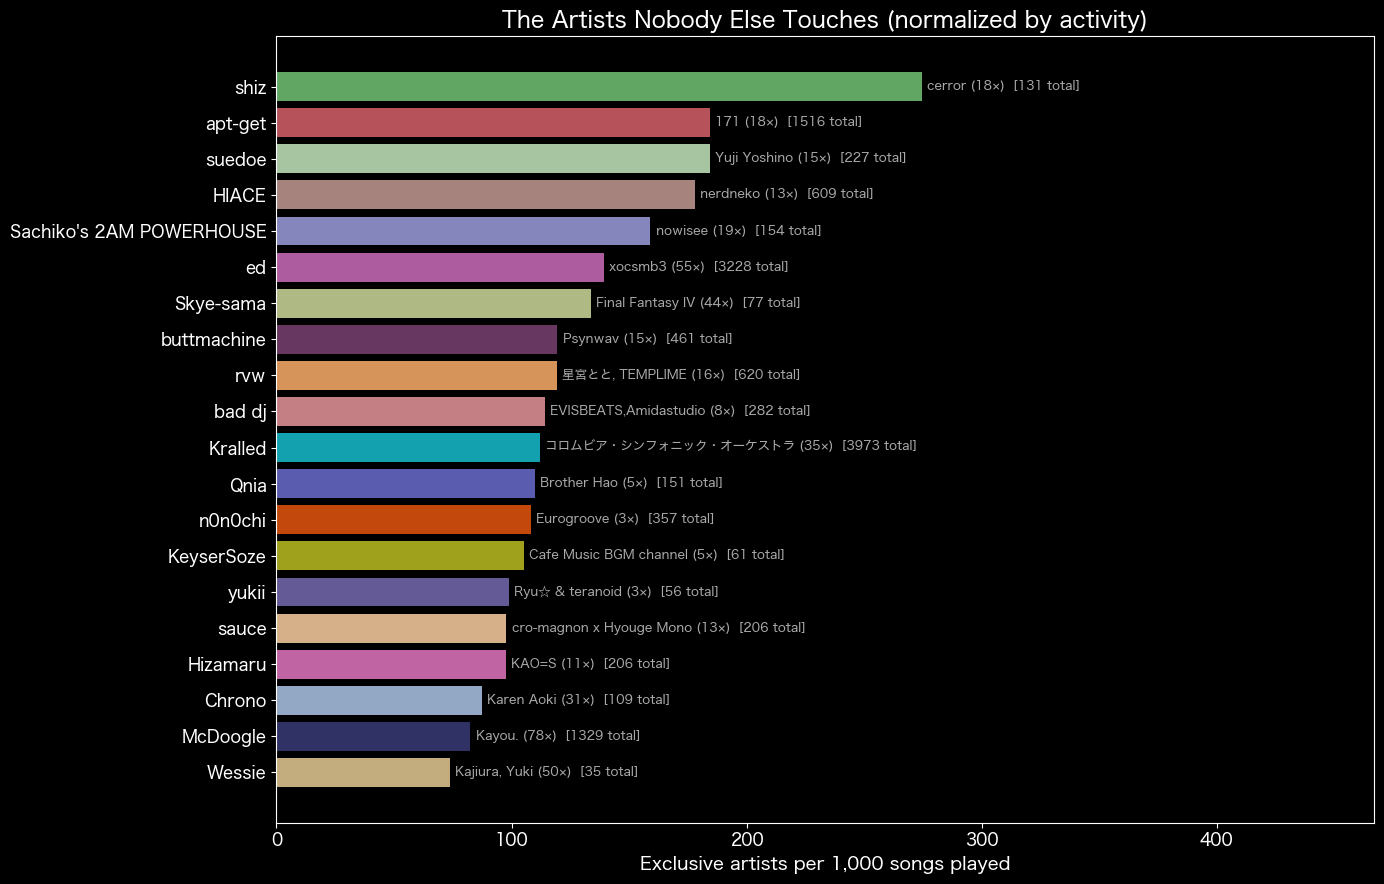


Uniqueness % (exclusive artists / total artists, min 30 sets):
  ed                   47% (3228 exclusive / 6853 artists, 23183 plays)
  apt-get              46% (1516 exclusive / 3310 artists, 8221 plays)
  HIACE                41% (609 exclusive / 1495 artists, 3424 plays)
  Ekureiru             40% (2249 exclusive / 5680 artists, 40732 plays)
  Kralled              37% (3973 exclusive / 10722 artists, 35400 plays)
  McDoogle             36% (1329 exclusive / 3676 artists, 16106 plays)
  rvw                  31% (620 exclusive / 2022 artists, 5202 plays)
  Master_Bacon         29% (1168 exclusive / 3997 artists, 16915 plays)
  buttmachine          28% (461 exclusive / 1660 artists, 3858 plays)
  Kilim                27% (275 exclusive / 1001 artists, 6836 plays)


In [5]:
# For each artist, which DJs play them? (exclude junk artists)
plays_real = plays_k[~plays_k['artist'].isin(JUNK_ARTISTS)]
artist_djs = plays_real.groupby('artist')['dj'].apply(set).reset_index()
artist_djs.columns = ['artist', 'dj_set']
artist_djs['n_djs'] = artist_djs['dj_set'].apply(len)

# Exclusive artists = played by exactly 1 DJ
exclusive = artist_djs[artist_djs['n_djs'] == 1].copy()
exclusive['sole_dj'] = exclusive['dj_set'].apply(lambda x: list(x)[0])

# Count plays per exclusive artist
excl_plays = plays_real.merge(exclusive[['artist', 'sole_dj']], on='artist')
excl_plays = excl_plays[excl_plays['dj'] == excl_plays['sole_dj']]
excl_artist_counts = excl_plays.groupby(['sole_dj', 'artist']).size().reset_index(name='plays')

# Per DJ: count of exclusive artists + top exclusive artist
excl_per_dj = excl_artist_counts.groupby('sole_dj').agg(
    n_exclusive=('artist', 'count'),
    total_excl_plays=('plays', 'sum')
).reset_index()

top_excl_artist = excl_artist_counts.sort_values('plays', ascending=False).groupby('sole_dj').first().reset_index()
top_excl_artist = top_excl_artist.rename(columns={'artist': 'top_artist', 'plays': 'top_artist_plays'})
excl_per_dj = excl_per_dj.merge(top_excl_artist[['sole_dj', 'top_artist', 'top_artist_plays']], on='sole_dj')

# Total unique artists and total plays per DJ for normalization
dj_total_artists = plays_real.groupby('dj')['artist'].nunique().reset_index(name='total_artists')
dj_total_plays_real = plays_real.groupby('dj').size().reset_index(name='total_plays')
excl_per_dj = excl_per_dj.merge(dj_total_artists, left_on='sole_dj', right_on='dj').drop(columns='dj')
excl_per_dj = excl_per_dj.merge(dj_total_plays_real, left_on='sole_dj', right_on='dj').drop(columns='dj')
excl_per_dj['excl_pct'] = excl_per_dj['n_exclusive'] / excl_per_dj['total_artists']

# Normalize: exclusive artists per 1000 songs played
excl_per_dj['excl_per_1k'] = excl_per_dj['n_exclusive'] / excl_per_dj['total_plays'] * 1000

# Plot: normalized by total songs played
excl_per_dj_plot = excl_per_dj.merge(n_sets_per_dj.rename('n_sets'), left_on='sole_dj', right_index=True)
excl_per_dj_plot = excl_per_dj_plot[excl_per_dj_plot['n_sets'] >= 10]
top20 = excl_per_dj_plot.sort_values('excl_per_1k', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(range(len(top20)), top20['excl_per_1k'],
               color=[DJ_COLORS.get(d, 'white') for d in top20['sole_dj']], alpha=0.85)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['sole_dj'])
ax.invert_yaxis()
ax.set_xlabel('Exclusive artists per 1,000 songs played')
ax.set_title('The Artists Nobody Else Touches (normalized by activity)')

for i, (_, r) in enumerate(top20.iterrows()):
    label = f" {r['top_artist']} ({r['top_artist_plays']:.0f}×)  [{r['n_exclusive']:.0f} total]"
    ax.text(r['excl_per_1k'] + 0.5, i, label, va='center', fontsize=9, color='#aaaaaa')

ax.set_xlim(0, top20['excl_per_1k'].max() * 1.7)
plt.tight_layout()
plt.show()

# Print uniqueness %
print("\nUniqueness % (exclusive artists / total artists, min 30 sets):")
pct_df = excl_per_dj_plot[excl_per_dj_plot['n_sets'] >= 30].sort_values('excl_pct', ascending=False)
for _, r in pct_df.head(10).iterrows():
    print(f"  {r['sole_dj']:20s} {r['excl_pct']:.0%} ({r['n_exclusive']:.0f} exclusive / {r['total_artists']} artists, {r['total_plays']} plays)")

---
## 3. Taste Twins & Complete Aliens
*Who sounds like who? Cosine similarity of DJ artist vectors.*

TASTE TWINS — Most similar DJ pairs (0-100 scale, 30+ sets each):
  Kralled            ↔ Suzubrah            100.0  (bonded by MAN WITH A MISSION)
  Kralled            ↔ Pachy                95.4  (bonded by MAN WITH A MISSION)


  Kralled            ↔ Master_Bacon         90.4  (bonded by アフィリア・サーガ)
  Kralled            ↔ n0n0chi              89.1  (bonded by Nhato)


  Ekureiru           ↔ Kralled              87.3  (bonded by 3L)
  Kralled            ↔ jii-san              82.6  (bonded by MAN WITH A MISSION)
  Kralled            ↔ Shavadava            82.0  (bonded by MAN WITH A MISSION)


  Kralled            ↔ Yorozuya             77.3  (bonded by MAN WITH A MISSION)
  Kethsar            ↔ ed                   76.6  (bonded by Demetori)
  Master_Bacon       ↔ Shavadava            76.3  (bonded by アフィリア・サーガ)

COMPLETE ALIENS — Most isolated DJs:
  Kilim               avg:  10.7  (closest: Claud at 53.0)
  apt-get             avg:  14.7  (closest: Kralled at 46.0)
  bad dj              avg:  15.9  (closest: Kralled at 55.1)
  Eggmun              avg:  16.1  (closest: Claud at 41.5)
  HIACE               avg:  16.3  (closest: Kralled at 38.6)
  buttmachine         avg:  18.3  (closest: Kralled at 61.5)
  sauce               avg:  20.1  (closest: n0n0chi at 71.1)
  kipukun             avg:  20.9  (closest: Kralled at 51.7)


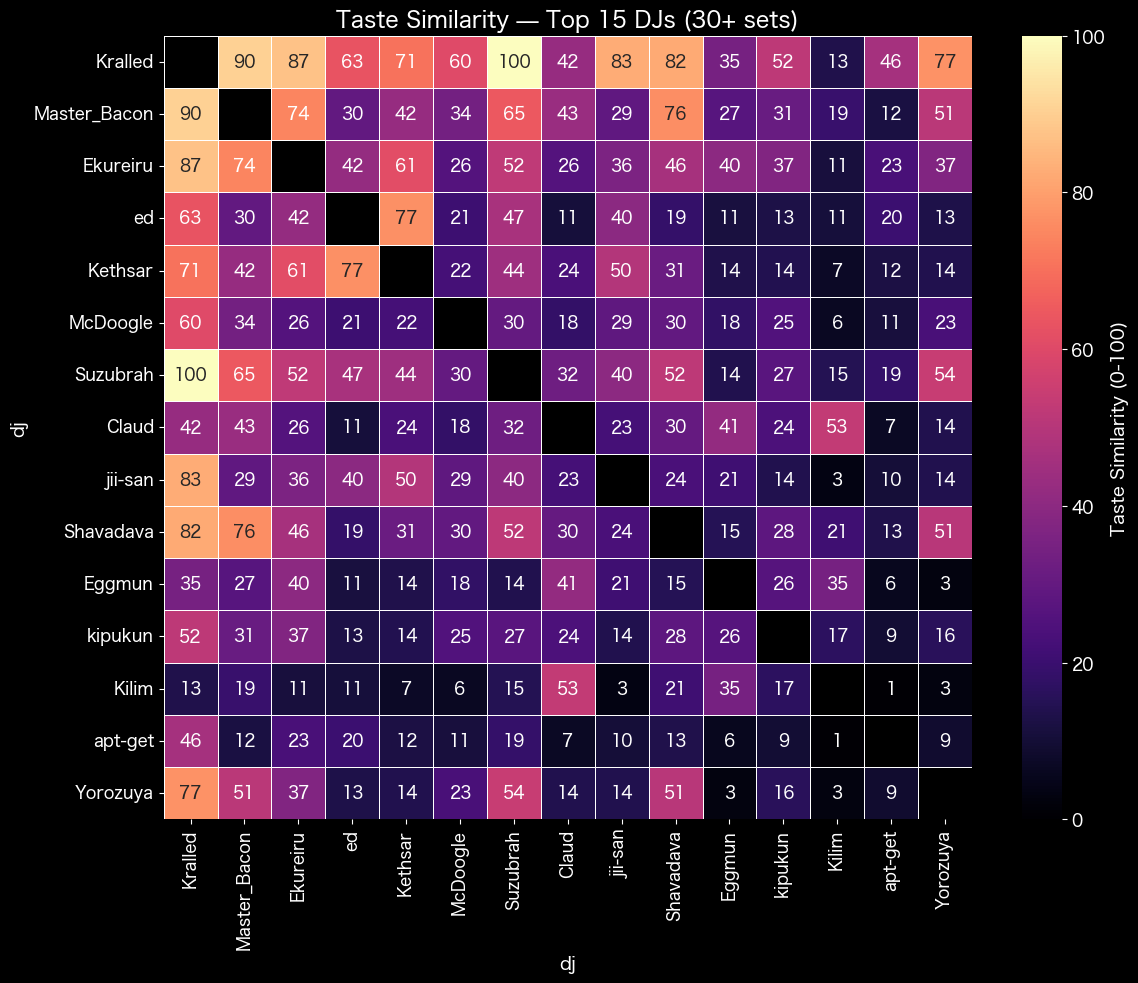


Most universal artist (played by N DJs):
artist
FLOW                    37
MAN WITH A MISSION      35
ClariS                  32
Abingdon Boys School    30
supercell               30


In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# Build DJ-artist matrix — exclude junk artists
plays_sim = plays_k[~plays_k['artist'].isin(JUNK_ARTISTS)]
dj_artist = plays_sim.groupby(['dj', 'artist']).size().reset_index(name='count')
dj_totals = dj_artist.groupby('dj')['count'].sum().rename('total')
dj_artist = dj_artist.merge(dj_totals, on='dj')
dj_artist['tf'] = dj_artist['count'] / dj_artist['total']

# IDF
n_djs = plays_sim['dj'].nunique()
artist_doc_freq = dj_artist.groupby('artist')['dj'].nunique().rename('df')
dj_artist = dj_artist.merge(artist_doc_freq, on='artist')
dj_artist['tfidf'] = dj_artist['tf'] * np.log(n_djs / dj_artist['df'])

# Pivot to matrix
mat = dj_artist.pivot_table(index='dj', columns='artist', values='tfidf', fill_value=0)

# Filter to DJs with >= 30 sets (meaningful sample)
active_djs = sets_k.groupby('dj').size()
active_djs = active_djs[active_djs >= 30].index
mat_filtered = mat.loc[mat.index.isin(active_djs)]

sim_raw = cosine_similarity(mat_filtered.values)
sim_raw_df = pd.DataFrame(sim_raw, index=mat_filtered.index, columns=mat_filtered.index)

# Normalize to 0-100 scale for readability
# Use min-max of off-diagonal values
off_diag = sim_raw[~np.eye(sim_raw.shape[0], dtype=bool)]
sim_min, sim_max = off_diag.min(), off_diag.max()
sim_norm = (sim_raw - sim_min) / (sim_max - sim_min) * 100
np.fill_diagonal(sim_norm, 100)
sim_df = pd.DataFrame(sim_norm, index=mat_filtered.index, columns=mat_filtered.index)

# Top pairs
pairs = []
for i, d1 in enumerate(sim_df.index):
    for j, d2 in enumerate(sim_df.columns):
        if i < j:
            pairs.append((d1, d2, sim_df.iloc[i, j], sim_raw_df.iloc[i, j]))
pairs_df = pd.DataFrame(pairs, columns=['dj1', 'dj2', 'score', 'raw_cos'])

print("TASTE TWINS — Most similar DJ pairs (0-100 scale, 30+ sets each):")
for _, r in pairs_df.sort_values('score', ascending=False).head(10).iterrows():
    # Find shared top artist — only artists both DJs play
    shared = dj_artist[(dj_artist['dj'].isin([r['dj1'], r['dj2']])) & (dj_artist['count'] >= 5)]
    both = shared.groupby('artist').filter(lambda g: g['dj'].nunique() == 2)
    shared_artists = both.groupby('artist')['count'].sum().sort_values(ascending=False)
    bond = shared_artists.index[0] if len(shared_artists) > 0 else '?'
    print(f"  {r['dj1']:18s} ↔ {r['dj2']:18s}  {r['score']:5.1f}  (bonded by {bond})")

print("\nCOMPLETE ALIENS — Most isolated DJs:")
avg_sim = sim_df.where(sim_df < 100).mean(axis=1).sort_values()
for dj, s in avg_sim.head(8).items():
    max_pair = sim_df.loc[dj].where(sim_df.loc[dj] < 100).idxmax()
    max_val = sim_df.loc[dj].where(sim_df.loc[dj] < 100).max()
    print(f"  {dj:18s}  avg: {s:5.1f}  (closest: {max_pair} at {max_val:.1f})")

# Heatmap of top 15 most active DJs (from the 30+ set pool)
top15 = sets_k[sets_k['dj'].isin(sim_df.index)].groupby('dj').size().sort_values(ascending=False).head(15).index
top15 = [d for d in top15 if d in sim_df.index]
sub = sim_df.loc[top15, top15]

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(sub), dtype=bool)
sns.heatmap(sub, mask=mask, cmap='magma', vmin=0, vmax=100,
            annot=True, fmt='.0f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Taste Similarity (0-100)'})
ax.set_title('Taste Similarity — Top 15 DJs (30+ sets)')
plt.tight_layout()
plt.show()

# Most universal artist
print(f"\nMost universal artist (played by N DJs):\n{artist_doc_freq.sort_values(ascending=False).head(5).to_string()}")

---
## 4. One-Trick Ponies vs The Eclectics
*What % of your plays are just your top 5 artists?*

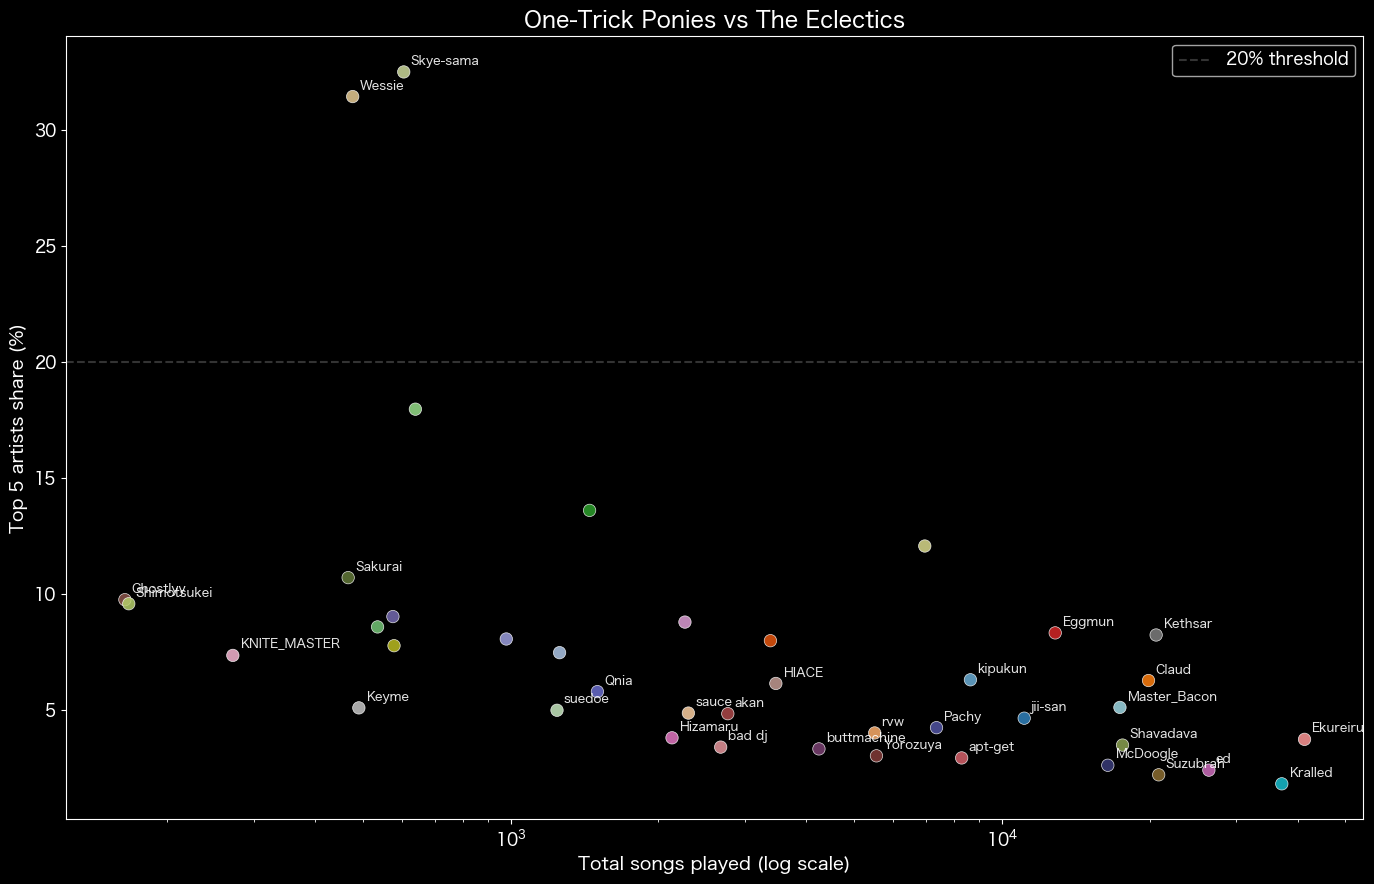

Most concentrated (top-5 artist share):
  Skye-sama             32.5%  (top: toby fox, 11.7%)
  Wessie                31.4%  (top: Kajiura, Yuki, 10.5%)
  DynamicEntry          18.0%  (top: 河井英里, 9.7%)
  DigitalHoarder        13.6%  (top: Joe Hisaishi, 3.3%)
  Kilim                 12.1%  (top: Yasunori Mitsuda, 3.6%)
  Sakurai               10.7%  (top: トゲナシトゲアリ, 4.7%)
  Ghostlyy               9.8%  (top: ナノ, 2.4%)
  Shimotsukei            9.6%  (top: Rita, 3.6%)

Most eclectic (top-5 artist share):
  Kralled                1.8%  (37144 songs, top: MAN WITH A MISSION)
  Suzubrah               2.2%  (20858 songs, top: Helblinde)
  ed                     2.4%  (26390 songs, top: Nhato)
  McDoogle               2.6%  (16432 songs, top: 東京事変)
  apt-get                2.9%  (8283 songs, top: 大森靖子)
  Yorozuya               3.0%  (5556 songs, top: チト(CV.水瀬いのり)、ユーリ(CV.久保ユリカ))
  buttmachine            3.3%  (4243 songs, top: Jackson Browne)
  bad dj                 3.4%  (2677 songs, top: tofu

In [7]:
# For each DJ: top-5 artist share (excluding junk artists)
dj_artist_counts = plays_k[~plays_k['artist'].isin(JUNK_ARTISTS)].groupby(['dj', 'artist']).size().reset_index(name='count')
dj_total_plays = plays_k.groupby('dj').size().rename('total')

def top5_share(group):
    return group.nlargest(5, 'count')['count'].sum()

t5 = dj_artist_counts.groupby('dj').apply(top5_share).rename('top5_plays').to_frame()
t5 = t5.merge(dj_total_plays, on='dj')
t5['top5_pct'] = t5['top5_plays'] / t5['total'] * 100

# Top-1 named artist for labeling
top1 = dj_artist_counts.sort_values('count', ascending=False).groupby('dj').first().reset_index()
top1_total = top1.merge(dj_total_plays, on='dj')
top1['top1_pct'] = top1_total['count'] / top1_total['total'] * 100
t5 = t5.merge(top1[['dj', 'artist', 'top1_pct']], on='dj', how='left')
t5 = t5.rename(columns={'artist': 'top_artist'}).set_index('dj')

# Filter to DJs with >= 5 sets
active5 = sets_k.groupby('dj').size()
active5 = active5[active5 >= 5].index
t5_plot = t5[t5.index.isin(active5)].copy()

fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(t5_plot['total'], t5_plot['top5_pct'],
           c=[DJ_COLORS.get(d, 'white') for d in t5_plot.index],
           s=80, alpha=0.85, edgecolors='white', linewidth=0.5)

for dj in t5_plot.index:
    r = t5_plot.loc[dj]
    if r['top5_pct'] > 25 or r['total'] > 12000 or r['top5_pct'] < 7 or r['total'] < 500:
        ax.annotate(dj, (r['total'], r['top5_pct']),
                    fontsize=9, color='white', alpha=0.9,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xscale('log')
ax.set_xlabel('Total songs played (log scale)')
ax.set_ylabel('Top 5 artists share (%)')
ax.set_title('One-Trick Ponies vs The Eclectics')
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.4, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print("Most concentrated (top-5 artist share):")
for dj in t5_plot.sort_values('top5_pct', ascending=False).head(8).index:
    r = t5_plot.loc[dj]
    print(f"  {dj:20s} {r['top5_pct']:5.1f}%  (top: {r['top_artist']}, {r['top1_pct']:.1f}%)")

print("\nMost eclectic (top-5 artist share):")
for dj in t5_plot.sort_values('top5_pct').head(8).index:
    r = t5_plot.loc[dj]
    print(f"  {dj:20s} {r['top5_pct']:5.1f}%  ({r['total']:.0f} songs, top: {r['top_artist']})")

---
## 5. The Normie Index
*Who carries the station's FLOW quota? Who plays the most overplayed tracks?*

Station's top 10 most-played songs:
    771×  FLOW - COLORS
    507×  アフィリア・サーガ - ネプチューヌ☆サガして
    481×  Supercell - Feel so good
    444×  Nothing's Carved in Stone - Out of Control
    424×  MAN WITH A MISSION - Raise your flag
    310×  #comiket - trainroll
    307×  Kaneda Tomoko - Ganbara
    302×  Lucy Rose - Shiver
    271×  Abingdon Boys School - Howling
    257×  MAN WITH A MISSION - database feat.TAKUMA(10-FEET)


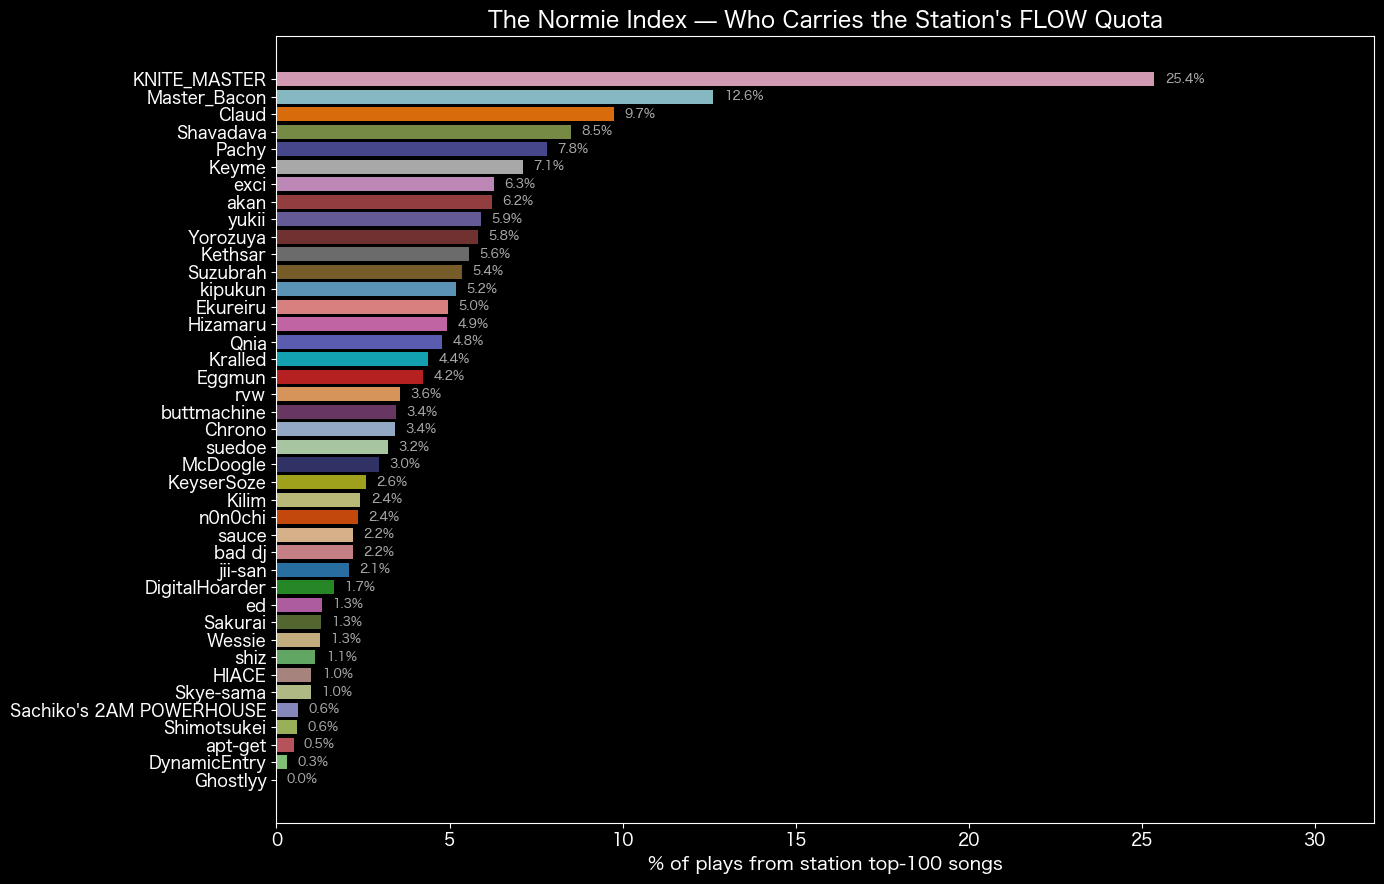

In [8]:
# Station's top 100 most-played songs
global_song_counts = plays_k.groupby('song').size().sort_values(ascending=False)
top100_songs = set(global_song_counts.head(100).index)

print("Station's top 10 most-played songs:")
for song, count in global_song_counts.head(10).items():
    print(f"  {count:5d}×  {song[:70]}")

# Per DJ: what % of their plays are top-100 songs?
plays_k_copy = plays_k.copy()
plays_k_copy['is_top100'] = plays_k_copy['song'].isin(top100_songs)

normie = plays_k_copy.groupby('dj').agg(
    top100_plays=('is_top100', 'sum'),
    total_plays=('song', 'count')
).reset_index()
normie['normie_pct'] = normie['top100_plays'] / normie['total_plays'] * 100

# Filter to active DJs
normie = normie.merge(n_sets_per_dj.rename('n_sets'), left_on='dj', right_index=True)
normie = normie[normie['n_sets'] >= 5].sort_values('normie_pct', ascending=False)

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(range(len(normie)), normie['normie_pct'],
               color=[DJ_COLORS.get(d, 'white') for d in normie['dj']], alpha=0.85)
ax.set_yticks(range(len(normie)))
ax.set_yticklabels(normie['dj'])
ax.invert_yaxis()
ax.set_xlabel('% of plays from station top-100 songs')
ax.set_title('The Normie Index — Who Carries the Station\'s FLOW Quota')

for i, (_, r) in enumerate(normie.iterrows()):
    ax.text(r['normie_pct'] + 0.3, i, f"{r['normie_pct']:.1f}%", va='center', fontsize=9, color='#aaaaaa')

ax.set_xlim(0, normie['normie_pct'].max() * 1.25)
plt.tight_layout()
plt.show()

---
## 6. Oldfags & Newfags — The Era Divide
*When were a DJ's songs first heard on the station? Who's stuck in 2012 and who only plays last season?*

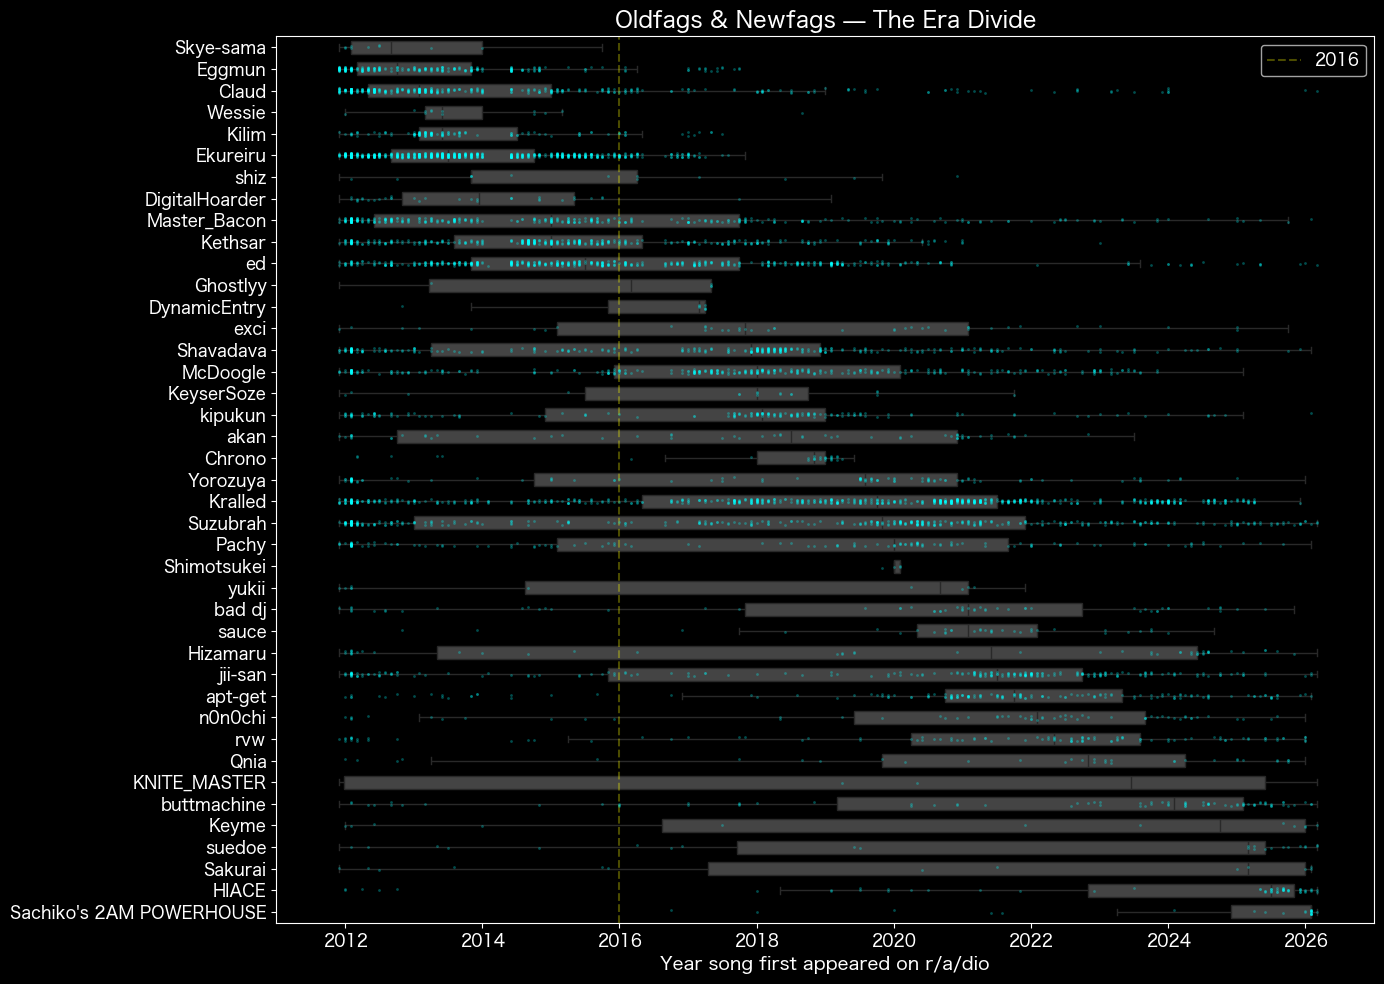

Oldest median era (oldfags):
  Skye-sama            median: 2012-09
  Eggmun               median: 2012-10
  Claud                median: 2013-01
  Wessie               median: 2013-06
  Kilim                median: 2013-06
  Ekureiru             median: 2013-07
  shiz                 median: 2013-10
  DigitalHoarder       median: 2013-12

Newest median era (newfags):
  Sachiko's 2AM POWERHOUSE median: 2026-01
  HIACE                median: 2025-07
  Sakurai              median: 2025-03
  suedoe               median: 2025-03
  Keyme                median: 2024-10
  buttmachine          median: 2024-01
  KNITE_MASTER         median: 2023-06
  Qnia                 median: 2022-10


In [9]:
# For each song, find when it first appeared on the station
song_first_seen = plays.groupby('song')['set_start'].min().rename('first_seen')

# Merge onto plays (keep as datetime for proper axis)
plays_era = plays_k.merge(song_first_seen, on='song', how='left')
# Convert to fractional year for boxplot
plays_era['era_year'] = plays_era['first_seen'].dt.year + plays_era['first_seen'].dt.month / 12

# Per DJ: distribution of song eras
dj_eras = plays_era.groupby('dj')['era_year'].agg(['median', 'mean']).reset_index()
dj_eras = dj_eras.merge(n_sets_per_dj.rename('n_sets'), left_on='dj', right_index=True)
dj_eras = dj_eras[dj_eras['n_sets'] >= 5].sort_values('median')

# Box/strip plot
active_for_plot = dj_eras['dj'].values
era_data = plays_era[plays_era['dj'].isin(active_for_plot)]
dj_order = dj_eras.sort_values('median')['dj'].values

fig, ax = plt.subplots(figsize=(14, 10))
sns.boxplot(data=era_data, y='dj', x='era_year', order=dj_order,
            color='#444444', fliersize=0, ax=ax, width=0.6)
sns.stripplot(data=era_data.sample(frac=0.02, random_state=42),
              y='dj', x='era_year', order=dj_order,
              color='cyan', alpha=0.3, size=2, ax=ax, jitter=True)

# Clean x-axis: show whole years only
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.set_xlim(2011, 2027)

ax.set_xlabel('Year song first appeared on r/a/dio')
ax.set_ylabel('')
ax.set_title('Oldfags & Newfags — The Era Divide')
ax.axvline(x=2016, color='yellow', linestyle='--', alpha=0.3, label='2016')
ax.legend()
plt.tight_layout()
plt.show()

print("Oldest median era (oldfags):")
for _, r in dj_eras.head(8).iterrows():
    yr = int(r['median'])
    mo = int((r['median'] - yr) * 12) + 1
    print(f"  {r['dj']:20s} median: {yr}-{mo:02d}")

print("\nNewest median era (newfags):")
for _, r in dj_eras.tail(8).iloc[::-1].iterrows():
    yr = int(r['median'])
    mo = int((r['median'] - yr) * 12) + 1
    print(f"  {r['dj']:20s} median: {yr}-{mo:02d}")

---
## 7. Christmas Marathon — Holiday Endurance
*The annual December tradition: who shows up every year?*

Christmas sets (Dec 20-31): 338


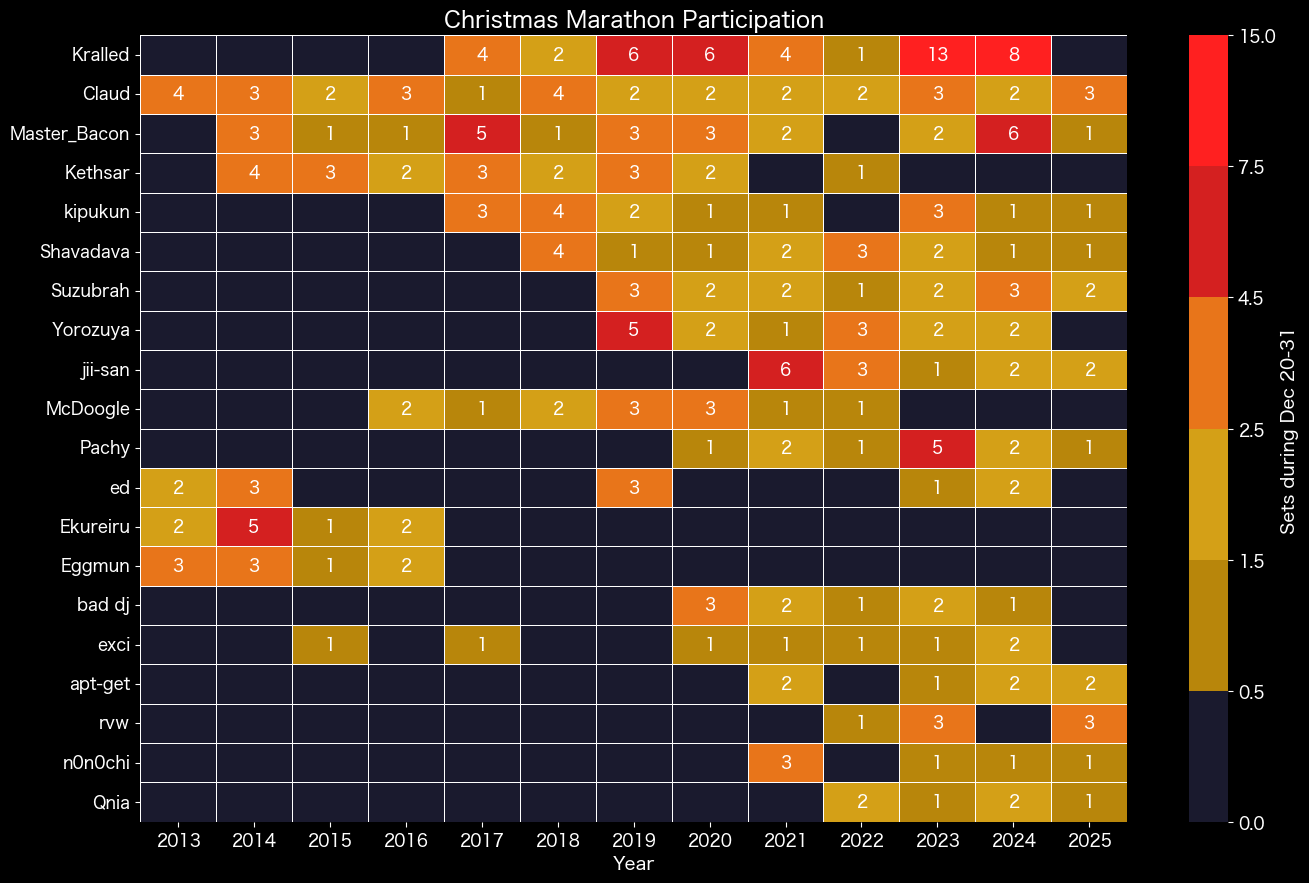


Marathon growth:
  2013:  13 sets by  6 DJs
  2014:  22 sets by  7 DJs
  2015:  10 sets by  7 DJs
  2016:  14 sets by  8 DJs
  2017:  20 sets by  9 DJs
  2018:  21 sets by  8 DJs
  2019:  33 sets by 11 DJs
  2020:  32 sets by 14 DJs
  2021:  34 sets by 16 DJs
  2022:  21 sets by 13 DJs
  2023:  45 sets by 18 DJs
  2024:  41 sets by 17 DJs
  2025:  32 sets by 21 DJs

Most years appeared:
  Claud                13 Christmases (33 total sets)
  Master_Bacon         11 Christmases (28 total sets)
  Shavadava            8 Christmases (15 total sets)
  Kethsar              8 Christmases (20 total sets)
  kipukun              8 Christmases (16 total sets)
  Kralled              8 Christmases (44 total sets)
  McDoogle             7 Christmases (13 total sets)
  Suzubrah             7 Christmases (15 total sets)
  exci                 7 Christmases (8 total sets)
  Pachy                6 Christmases (12 total sets)


In [10]:
# Christmas sets: Dec 20-31
sets_k['month'] = sets_k['start'].dt.month
sets_k['day'] = sets_k['start'].dt.day
sets_k['year'] = sets_k['start'].dt.year

xmas = sets_k[(sets_k['month'] == 12) & (sets_k['day'] >= 20)].copy()
print(f"Christmas sets (Dec 20-31): {len(xmas)}")

# DJ × year participation
xmas_participation = xmas.groupby(['dj', 'year']).size().reset_index(name='n_sets')
xmas_pivot = xmas_participation.pivot_table(index='dj', columns='year', values='n_sets', fill_value=0).astype(int)

# Sort by total participation
xmas_pivot['total'] = xmas_pivot.sum(axis=1)
xmas_pivot = xmas_pivot.sort_values('total', ascending=False)
xmas_total = xmas_pivot.pop('total')

top_xmas = xmas_pivot.head(20)

# Annotation: show number for 1+, blank for 0
annot = top_xmas.astype(str).replace('0', '')

fig, ax = plt.subplots(figsize=(14, 9))
from matplotlib.colors import ListedColormap, BoundaryNorm

bounds = [0, 0.5, 1.5, 2.5, 4.5, 7.5, 15]
colors_list = ['#1a1a2e', '#b8860b', '#d4a017', '#e8751a', '#d42020', '#ff2020']
cmap_custom = ListedColormap(colors_list)
norm = BoundaryNorm(bounds, cmap_custom.N)

sns.heatmap(top_xmas, cmap=cmap_custom, norm=norm,
            annot=annot, fmt='s', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Sets during Dec 20-31'})
ax.set_title('Christmas Marathon Participation')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Marathon growth
yearly_total = xmas.groupby('year').size()
yearly_djs = xmas.groupby('year')['dj'].nunique()

print("\nMarathon growth:")
for yr in sorted(yearly_total.index):
    print(f"  {yr}: {yearly_total[yr]:3d} sets by {yearly_djs[yr]:2d} DJs")

# Most dedicated (appeared in most different years)
years_appeared = xmas_participation.groupby('dj')['year'].nunique().sort_values(ascending=False)
print("\nMost years appeared:")
for dj, n in years_appeared.head(10).items():
    total_sets = xmas_total.get(dj, 0)
    print(f"  {dj:20s} {n} Christmases ({total_sets} total sets)")